# 01_reconstruct_l2_book

## Goal

This notebook reconstructs an L2 order book from:

- `snapshot` (initial full book state)
- `depthdiff` (incremental updates)

Optional inputs:

- `depth20_100ms` for validation
- `trade` for future extensions

## Real data layout

This notebook is designed for a directory structure like:

`/Volumes/Profit/bitcoin_tickets/{spots|futures}/{symbol}/YYYYMMDD/HH/{stream_type}/*.jsonl...`

where each hourly folder may contain:

- `snapshot`
- `depthdiff`
- `depth20_100ms`
- `trade`
- `aggtrade`
- `bookticker`

## Outputs

This notebook is designed to produce:

1. `book_event_summary_YYYYMMDD_HH.parquet`
2. `book_top20_sampled_YYYYMMDD_HH.parquet`
3. `reconstruction_diagnostics_YYYYMMDD_HH.parquet`

and optionally combined outputs:

4. `book_event_summary.parquet`
5. `book_top20_sampled.parquet`
6. `reconstruction_diagnostics.parquet`
7. `book_validation_report.parquet`

## Notes

- This notebook focuses on **book reconstruction**, not strategy backtesting.
- The intended design is **streaming / memory-aware**.
- We do **not** aggregate raw diff events before reconstruction.
- We may aggregate **derived features after reconstruction**.
- Reconstruction is performed **session by session (hour by hour)**.

In [2]:
# =========================================
# 1. Imports
# =========================================

import os
import json
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Iterator, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import zstandard as zstd
except ImportError:
    raise ImportError("Please install zstandard: pip install zstandard")

## Configuration

Edit this section first.

Key design choices:

- reconstruct book at event level
- keep only current live book in memory
- run one hour/session at a time
- save outputs incrementally
- optionally validate against `depth20_100ms`

In [91]:
# =========================================
# 1b. User Config
# =========================================

BASE_ROOT = Path("/Volumes/Profit/bitcoin_ticks")

MARKET = "spot"       # "spots" or "futures"
SYMBOL = "btcusdt"

DATA_ROOT = BASE_ROOT / MARKET / SYMBOL
OUTPUT_ROOT = BASE_ROOT / "reconstructed_outputs" / MARKET / SYMBOL
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

START_DATE = '20251123'#"20251030"
END_DATE   = '20251210'#"20260310"

TOP_N_SAVE = 20
DEPTH_SUMMARY_LEVELS = [5, 10, 20]

# sampling mode:
#   "event" -> save top-N at every diff event
#   "time"  -> save top-N every fixed milliseconds
SAMPLED_MODE = "time"
SAMPLED_EVERY_MS = 1000   # e.g. 100, 250, 1000

ENABLE_VALIDATION = True
ENABLE_QUICK_PLOTS = True
VERBOSE = True

FIGSIZE = (12, 5)

# 2. Notebook Plan & Data Assumptions

## Data assumptions

### `snapshot`
A full book snapshot with:

- `last_update_id`
- full `bids`
- full `asks`

### `depthdiff`
Incremental L2 updates with:

- `U`, `u` update ids
- bid updates `b`
- ask updates `a`

### `depth20_100ms`
Optional validation stream of top-20 states.

## Reconstruction rule

If the snapshot has `last_update_id = L`, find the first diff event such that:

- `U <= L + 1 <= u`

Then apply subsequent diff events in order.

## Session logic

Because the raw data is organized by hour folder, reconstruction is performed:

- one **hour/session** at a time
- one session = one hourly folder
- then results can be concatenated by day or globally

## Memory model

We keep only:

- the **current** book state
- rolling diagnostics
- accumulated summary rows / sampled rows for the current session

We do **not** keep the full historical book in memory.

In [92]:
# =========================================
# 3. Session Discovery
# =========================================

def list_date_dirs(data_root: Path) -> List[Path]:
    out = []
    if not data_root.exists():
        return out

    for p in sorted(data_root.iterdir()):
        if p.is_dir() and p.name.isdigit() and len(p.name) == 8:
            if START_DATE <= p.name <= END_DATE:
                out.append(p)
    return out

def list_hour_dirs(date_dir: Path) -> List[Path]:
    out = []
    for p in sorted(date_dir.iterdir()):
        if p.is_dir() and p.name.isdigit() and len(p.name) == 2:
            out.append(p)
    return out

date_dirs = list_date_dirs(DATA_ROOT)

print("DATA_ROOT   :", DATA_ROOT)
print("n_date_dirs :", len(date_dirs))
print("first dates :", [p.name for p in date_dirs[:5]])

DATA_ROOT   : /Volumes/Profit/bitcoin_ticks/spot/btcusdt
n_date_dirs : 18
first dates : ['20251123', '20251124', '20251125', '20251126', '20251127']


## Build hourly session map

We build a session map at the **hourly** level.

Each session contains file lists for:

- `snapshot`
- `depthdiff`
- `depth20_100ms`
- `trade`
- `aggtrade`
- `bookticker`

This is more natural for your data structure than a flat daily mapping.

In [93]:
# =========================================
# 3b. Build hourly session map
# =========================================

def collect_stream_files_from_hour(hour_dir: Path, stream_name: str) -> List[str]:
    stream_dir = hour_dir / stream_name
    if not stream_dir.exists() or not stream_dir.is_dir():
        return []
    return sorted(str(p) for p in stream_dir.glob("*.jsonl*") if p.is_file())

def build_hourly_session_map(data_root: Path) -> pd.DataFrame:
    rows = []

    for date_dir in list_date_dirs(data_root):
        date_str = date_dir.name

        for hour_dir in list_hour_dirs(date_dir):
            hour_str = hour_dir.name

            snapshot_files   = collect_stream_files_from_hour(hour_dir, "snapshot")
            depthdiff_files  = collect_stream_files_from_hour(hour_dir, "depthdiff")
            depth20_files    = collect_stream_files_from_hour(hour_dir, "depth20_100ms")
            trade_files      = collect_stream_files_from_hour(hour_dir, "trade")
            aggtrade_files   = collect_stream_files_from_hour(hour_dir, "aggtrade")
            bookticker_files = collect_stream_files_from_hour(hour_dir, "bookticker")

            rows.append({
                "date": date_str,
                "hour": hour_str,
                "session_id": f"{date_str}_{hour_str}",
                "hour_dir": str(hour_dir),

                "snapshot_files": snapshot_files,
                "depthdiff_files": depthdiff_files,
                "depth20_files": depth20_files,
                "trade_files": trade_files,
                "aggtrade_files": aggtrade_files,
                "bookticker_files": bookticker_files,

                "n_snapshot_files": len(snapshot_files),
                "n_depthdiff_files": len(depthdiff_files),
                "n_depth20_files": len(depth20_files),
                "n_trade_files": len(trade_files),
                "n_aggtrade_files": len(aggtrade_files),
                "n_bookticker_files": len(bookticker_files),
            })

    return pd.DataFrame(rows)

session_map = build_hourly_session_map(DATA_ROOT)

print("n_sessions:", len(session_map))
session_map.head(20)

n_sessions: 432


,date,hour,session_id,hour_dir,snapshot_files,depthdiff_files,depth20_files,trade_files,aggtrade_files,bookticker_files,n_snapshot_files,n_depthdiff_files,n_depth20_files,n_trade_files,n_aggtrade_files,n_bookticker_files
0,20251123,00,20251123_00,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,59,59,60,60,60
1,20251123,01,20251123_01,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,60,60,60,60,59
2,20251123,02,20251123_02,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,60,60,59,59,60
3,20251123,03,20251123_03,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,60,60,60,60,59
4,20251123,04,20251123_04,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,60,60,60,60,60
5,20251123,05,20251123_05,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,60,60,59,59,60
6,20251123,06,20251123_06,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,60,60,60,60,60
7,20251123,07,20251123_07,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,12,60,60,59,59,60
8,20251123,08,20251123_08,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,13,60,60,60,60,59
9,20251123,09,20251123_09,/Volumes/Profit/bitcoin_ticks/spot/btcusdt/202...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volumes/Profit/bitcoin_ticks/spot/btcusdt/20...,[/Volum

In [94]:
# Quick sanity on session coverage

if len(session_map) > 0:
    coverage = session_map.groupby("date").agg(
        n_sessions=("session_id", "size"),
        n_with_snapshot=("n_snapshot_files", lambda x: int((x > 0).sum())),
        n_with_depthdiff=("n_depthdiff_files", lambda x: int((x > 0).sum())),
        n_with_depth20=("n_depth20_files", lambda x: int((x > 0).sum())),
    ).reset_index()

    coverage.head(20)

# 4. Low-Level Readers for `.jsonl.zst`

The goal here is to stream records without loading the full file into memory.

In [95]:
# =========================================
# 4. Streaming readers
# =========================================

def iter_jsonl_zst(path: str) -> Iterator[dict]:
    with open(path, "rb") as f:
        dctx = zstd.ZstdDecompressor()
        with dctx.stream_reader(f) as reader:
            buffer = b""
            while True:
                chunk = reader.read(1 << 20)
                if not chunk:
                    break
                buffer += chunk
                while b"\n" in buffer:
                    line, buffer = buffer.split(b"\n", 1)
                    line = line.strip()
                    if not line:
                        continue
                    yield json.loads(line)
            if buffer.strip():
                yield json.loads(buffer)

def preview_jsonl_zst(path: str, n: int = 3):
    rows = []
    for i, obj in enumerate(iter_jsonl_zst(path)):
        rows.append(obj)
        if i + 1 >= n:
            break
    return rows

In [96]:
# Example preview helpers

def preview_first_file(file_list: List[str], n: int = 2):
    if len(file_list) == 0:
        print("No files available.")
        return []
    return preview_jsonl_zst(file_list[0], n=n)

# Example:
# preview_first_file(session_map.loc[0, "snapshot_files"], n=1)
# preview_first_file(session_map.loc[0, "depthdiff_files"], n=2)

# 5. Parsing Helpers

Standardize different raw event schemas into a common internal format.

You may need to tweak these if your exact JSON field names differ slightly.

In [ ]:
# =========================================
# 5. Parsing helpers
# =========================================

def parse_snapshot_event(raw: dict) -> dict:
    return {
        "event_time": int(raw.get("event_time", raw.get("E", 0))),
        "last_update_id": int(raw["last_update_id"]),
        "bids": raw["bids"],
        "asks": raw["asks"],
    }

def parse_depthdiff_event(raw: dict) -> dict:
    return {
        "event_time": int(raw.get("E", raw.get("event_time", 0))),
        "U": int(raw["U"]),
        "u": int(raw["u"]),
        "b": raw.get("b", []),
        "a": raw.get("a", []),
        "sequence_gap": bool(raw.get("sequence_gap", False)),
        "expected_start": raw.get("expected_start", None),
    }

def parse_depth20_event(raw: dict) -> dict:
    return {
        "event_time": int(raw.get("E", raw.get("event_time", 0))),
        "last_update_id": int(raw.get("last_update_id", raw.get("u", 0))),
        "bids": raw.get("bids", raw.get("b", [])),
        "asks": raw.get("asks", raw.get("a", [])),
    }

def parse_trade_event(raw: dict) -> dict:
    return {
        "event_time": int(raw.get("T", raw.get("event_time", 0))),
        "price": float(raw["p"]),
        "qty": float(raw["q"]),
        "trade_id": raw.get("t"),
        "is_buyer_maker": raw.get("m"),
    }

# 6. Core `BookState` Object

This object stores only the **current live book**.

In [ ]:
# =========================================
# 6. BookState
# =========================================

@dataclass
class BookState:
    bids: Dict[float, float]
    asks: Dict[float, float]
    last_update_id: int
    event_time: Optional[int] = None

    def best_bid(self) -> Optional[float]:
        return max(self.bids.keys()) if self.bids else None

    def best_ask(self) -> Optional[float]:
        return min(self.asks.keys()) if self.asks else None

    def mid(self) -> Optional[float]:
        bb = self.best_bid()
        ba = self.best_ask()
        if bb is None or ba is None:
            return None
        return 0.5 * (bb + ba)

    def spread(self) -> Optional[float]:
        bb = self.best_bid()
        ba = self.best_ask()
        if bb is None or ba is None:
            return None
        return ba - bb

    def top_n(self, n: int = 20) -> Tuple[List[Tuple[float, float]], List[Tuple[float, float]]]:
        top_bids = sorted(self.bids.items(), key=lambda x: x[0], reverse=True)[:n]
        top_asks = sorted(self.asks.items(), key=lambda x: x[0])[:n]
        return top_bids, top_asks

# 7. Snapshot Initialization

In [ ]:
# =========================================
# 7. Build book from snapshot
# =========================================

def build_book_from_snapshot(snapshot_event: dict) -> BookState:
    bids = {float(p): float(q) for p, q in snapshot_event["bids"] if float(q) > 0}
    asks = {float(p): float(q) for p, q in snapshot_event["asks"] if float(q) > 0}

    return BookState(
        bids=bids,
        asks=asks,
        last_update_id=int(snapshot_event["last_update_id"]),
        event_time=int(snapshot_event.get("event_time", 0)),
    )

# 8. Apply `depthdiff` Updates

Update logic:

- if size == 0: remove the level
- if size > 0: overwrite the level size

In [ ]:
# =========================================
# 8. Apply diff
# =========================================

def apply_depth_diff(book: BookState, diff_event: dict) -> None:
    for p, q in diff_event["b"]:
        p = float(p)
        q = float(q)
        if q == 0:
            book.bids.pop(p, None)
        else:
            book.bids[p] = q

    for p, q in diff_event["a"]:
        p = float(p)
        q = float(q)
        if q == 0:
            book.asks.pop(p, None)
        else:
            book.asks[p] = q

    book.last_update_id = int(diff_event["u"])
    book.event_time = int(diff_event.get("event_time", 0))

# 9. Align Snapshot to Diff Stream

Given snapshot `last_update_id = L`, the first valid diff event must satisfy:

- `U <= L + 1 <= u`

In [ ]:
# =========================================
# 9. Alignment helpers
# =========================================

def find_alignment_start_in_stream(diff_iter: Iterator[dict], snapshot_last_update_id: int):
    target = snapshot_last_update_id + 1
    n_skipped = 0

    for raw in diff_iter:
        d = parse_depthdiff_event(raw)
        if d["U"] <= target <= d["u"]:
            return d, n_skipped
        n_skipped += 1

    raise ValueError("Could not find valid diff alignment event for this snapshot.")

# 10. Event-Level Feature Extraction

In [ ]:
# =========================================
# 10. Feature extraction
# =========================================

def extract_top_level_features(book: BookState) -> dict:
    bb = book.best_bid()
    ba = book.best_ask()

    if bb is None or ba is None:
        return {
            "best_bid": np.nan,
            "best_ask": np.nan,
            "mid": np.nan,
            "spread": np.nan,
            "bid_size_1": np.nan,
            "ask_size_1": np.nan,
            "imbalance_1": np.nan,
            "microprice": np.nan,
        }

    bid_sz = float(book.bids.get(bb, 0.0))
    ask_sz = float(book.asks.get(ba, 0.0))
    denom = bid_sz + ask_sz

    imbalance = (bid_sz - ask_sz) / denom if denom > 0 else np.nan
    microprice = (ba * bid_sz + bb * ask_sz) / denom if denom > 0 else np.nan

    return {
        "best_bid": bb,
        "best_ask": ba,
        "mid": 0.5 * (bb + ba),
        "spread": ba - bb,
        "bid_size_1": bid_sz,
        "ask_size_1": ask_sz,
        "imbalance_1": imbalance,
        "microprice": microprice,
    }

def extract_depth_summaries(book: BookState, levels: List[int] = [5, 10, 20]) -> dict:
    top_bids, top_asks = book.top_n(max(levels))
    out = {}

    for k in levels:
        out[f"depth_bid_top{k}"] = float(sum(q for _, q in top_bids[:k]))
        out[f"depth_ask_top{k}"] = float(sum(q for _, q in top_asks[:k]))

    return out

def extract_book_summary(book: BookState, sequence_gap_flag: bool = False) -> dict:
    out = {
        "event_time": book.event_time,
        "last_update_id": book.last_update_id,
        "sequence_gap_flag": sequence_gap_flag,
    }
    out.update(extract_top_level_features(book))
    out.update(extract_depth_summaries(book, DEPTH_SUMMARY_LEVELS))
    return out

# 11. Top-N Snapshot Serialization

This is the main output for later:

- L2 visualization
- taker sweep simulation
- optional validation

In [ ]:
# =========================================
# 11. Serialize top-N
# =========================================

def serialize_top_n(book: BookState, n: int = 20) -> dict:
    top_bids, top_asks = book.top_n(n)

    row = {
        "event_time": book.event_time,
        "last_update_id": book.last_update_id,
    }

    for i in range(n):
        if i < len(top_bids):
            px, sz = top_bids[i]
            row[f"bid_px_{i+1}"] = px
            row[f"bid_sz_{i+1}"] = sz
        else:
            row[f"bid_px_{i+1}"] = np.nan
            row[f"bid_sz_{i+1}"] = np.nan

        if i < len(top_asks):
            px, sz = top_asks[i]
            row[f"ask_px_{i+1}"] = px
            row[f"ask_sz_{i+1}"] = sz
        else:
            row[f"ask_px_{i+1}"] = np.nan
            row[f"ask_sz_{i+1}"] = np.nan

    return row

def should_sample_event(current_event_time: int, last_sampled_time: Optional[int], mode: str, every_ms: int) -> bool:
    if mode == "event":
        return True
    if last_sampled_time is None:
        return True
    return (current_event_time - last_sampled_time) >= every_ms

# 12. Session-Level Reconstruction Loop

This is the core hourly/session reconstruction routine.

In [ ]:
# =========================================
# 12. Build file-time index within a session
# =========================================

def first_event_time_of_file(path: str, parser) -> int:
    raw = next(iter_jsonl_zst(path))
    evt = parser(raw)
    return evt["event_time"]

def build_session_file_time_index(snapshot_files: List[str], depthdiff_files: List[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    snap_rows = []
    for f in snapshot_files:
        try:
            t = first_event_time_of_file(f, parse_snapshot_event)
            snap_rows.append({
                "snapshot_file": f,
                "snapshot_time": t,
                "snapshot_name": Path(f).name,
            })
        except Exception as e:
            snap_rows.append({
                "snapshot_file": f,
                "snapshot_time": np.nan,
                "snapshot_name": Path(f).name,
                "error": str(e),
            })

    diff_rows = []
    for f in depthdiff_files:
        try:
            t = first_event_time_of_file(f, parse_depthdiff_event)
            diff_rows.append({
                "depthdiff_file": f,
                "depthdiff_time": t,
                "depthdiff_name": Path(f).name,
            })
        except Exception as e:
            diff_rows.append({
                "depthdiff_file": f,
                "depthdiff_time": np.nan,
                "depthdiff_name": Path(f).name,
                "error": str(e),
            })

    snap_df = pd.DataFrame(snap_rows).sort_values("snapshot_time").reset_index(drop=True)
    diff_df = pd.DataFrame(diff_rows).sort_values("depthdiff_time").reset_index(drop=True)

    return snap_df, diff_df

In [ ]:
#=======================================

# =========================================
# 12b. Split one session into snapshot-diff segments
#     (include one bridging diff file before snapshot)
# =========================================

def build_snapshot_segments(snapshot_files: List[str], depthdiff_files: List[str]) -> List[dict]:
    snap_df, diff_df = build_session_file_time_index(snapshot_files, depthdiff_files)

    segments = []

    if len(snap_df) == 0 or len(diff_df) == 0:
        return segments

    snap_times = snap_df["snapshot_time"].tolist()

    for i, row in snap_df.iterrows():
        snap_file = row["snapshot_file"]
        snap_time = row["snapshot_time"]
        next_snap_time = snap_times[i + 1] if i + 1 < len(snap_times) else np.inf

        # main window: diffs from snapshot_time until next snapshot
        main_mask = (diff_df["depthdiff_time"] >= snap_time) & (diff_df["depthdiff_time"] < next_snap_time)
        main_files = diff_df.loc[main_mask, "depthdiff_file"].tolist()

        # bridging file: the latest diff file strictly before snapshot_time
        prev_mask = diff_df["depthdiff_time"] < snap_time
        prev_files = diff_df.loc[prev_mask, "depthdiff_file"].tolist()
        bridge_file = prev_files[-1] if len(prev_files) > 0 else None

        seg_files = []
        if bridge_file is not None:
            seg_files.append(bridge_file)
        seg_files.extend(main_files)

        # deduplicate while preserving order
        seen = set()
        seg_files = [f for f in seg_files if not (f in seen or seen.add(f))]

        segments.append({
            "snapshot_file": snap_file,
            "snapshot_time": snap_time,
            "next_snapshot_time": next_snap_time,
            "depthdiff_files": seg_files,
            "n_depthdiff_files": len(seg_files),
            "bridge_file": bridge_file,
        })

    return segments

def get_unassigned_depthdiff_files(snapshot_files: List[str], depthdiff_files: List[str]):
    segments = build_snapshot_segments(snapshot_files, depthdiff_files)

    assigned = set()
    for seg in segments:
        assigned.update(seg["depthdiff_files"])

    all_files = set(depthdiff_files)
    unassigned = sorted(all_files - assigned)
    return unassigned

In [ ]:
# =========================================
# 12c. Reconstruct one snapshot segment
# =========================================

def reconstruct_one_segment(
    date: str,
    hour: str,
    segment_id: int,
    snapshot_file: str,
    depthdiff_files: List[str],
    sampled_mode: str = "time",
    sampled_every_ms: int = 1000,
):
    if snapshot_file is None:
        raise ValueError(f"[{date} {hour} seg={segment_id}] snapshot_file is None")
    if len(depthdiff_files) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame([{
            "date": date,
            "hour": hour,
            "segment_id": segment_id,
            "snapshot_file": snapshot_file,
            "aligned": False,
            "reason": "no_depthdiff_files_for_segment",
            "n_events_applied": 0,
            "n_sequence_gaps": 0,
            "n_crossed_book_events": 0,
            "n_invalid_events": 0,
        }])

    snap_raw = next(iter_jsonl_zst(snapshot_file))
    snap = parse_snapshot_event(snap_raw)
    book = build_book_from_snapshot(snap)

    summary_rows = []
    topn_rows = []

    diagnostics = {
        "date": date,
        "hour": hour,
        "session_id": f"{date}_{hour}",
        "segment_id": segment_id,
        "snapshot_file": snapshot_file,
        "snapshot_time": snap["event_time"],
        "snapshot_last_update_id": snap["last_update_id"],
        "aligned": False,
        "alignment_diff_time": None,
        "n_diff_files": len(depthdiff_files),
        "n_events_applied": 0,
        "n_sequence_gaps": 0,
        "n_crossed_book_events": 0,
        "n_invalid_events": 0,
    }

    aligned = False
    last_sampled_time = None

    for diff_path in depthdiff_files:
        diff_iter = iter_jsonl_zst(diff_path)

        if not aligned:
            try:
                first_valid_diff, n_skipped = find_alignment_start_in_stream(
                    diff_iter=diff_iter,
                    snapshot_last_update_id=book.last_update_id
                )
            except Exception:
                continue

            aligned = True
            diagnostics["aligned"] = True
            diagnostics["alignment_diff_time"] = first_valid_diff["event_time"]

            apply_depth_diff(book, first_valid_diff)
            seq_gap = bool(first_valid_diff.get("sequence_gap", False))
            if seq_gap:
                diagnostics["n_sequence_gaps"] += 1

            row = extract_book_summary(book, sequence_gap_flag=seq_gap)
            row["date"] = date
            row["hour"] = hour
            row["session_id"] = f"{date}_{hour}"
            row["segment_id"] = segment_id
            row["snapshot_file"] = snapshot_file
            row["source_file"] = str(diff_path)
            summary_rows.append(row)

            if should_sample_event(book.event_time, last_sampled_time, sampled_mode, sampled_every_ms):
                top_row = serialize_top_n(book, n=TOP_N_SAVE)
                top_row["date"] = date
                top_row["hour"] = hour
                top_row["session_id"] = f"{date}_{hour}"
                top_row["segment_id"] = segment_id
                top_row["snapshot_file"] = snapshot_file
                top_row["source_file"] = str(diff_path)
                topn_rows.append(top_row)
                last_sampled_time = book.event_time

            diagnostics["n_events_applied"] += 1

        for raw in diff_iter:
            d = parse_depthdiff_event(raw)

            try:
                apply_depth_diff(book, d)
            except Exception:
                diagnostics["n_invalid_events"] += 1
                continue

            seq_gap = bool(d.get("sequence_gap", False))
            if seq_gap:
                diagnostics["n_sequence_gaps"] += 1

            bb = book.best_bid()
            ba = book.best_ask()
            if bb is not None and ba is not None and bb >= ba:
                diagnostics["n_crossed_book_events"] += 1

            row = extract_book_summary(book, sequence_gap_flag=seq_gap)
            row["date"] = date
            row["hour"] = hour
            row["session_id"] = f"{date}_{hour}"
            row["segment_id"] = segment_id
            row["snapshot_file"] = snapshot_file
            row["source_file"] = str(diff_path)
            summary_rows.append(row)

            if should_sample_event(book.event_time, last_sampled_time, sampled_mode, sampled_every_ms):
                top_row = serialize_top_n(book, n=TOP_N_SAVE)
                top_row["date"] = date
                top_row["hour"] = hour
                top_row["session_id"] = f"{date}_{hour}"
                top_row["segment_id"] = segment_id
                top_row["snapshot_file"] = snapshot_file
                top_row["source_file"] = str(diff_path)
                topn_rows.append(top_row)
                last_sampled_time = book.event_time

            diagnostics["n_events_applied"] += 1

    return pd.DataFrame(summary_rows), pd.DataFrame(topn_rows), pd.DataFrame([diagnostics])

In [ ]:
# =========================================
# 12d. Reconstruct one full hourly session via multiple segments
# =========================================

def reconstruct_one_session(
    date: str,
    hour: str,
    snapshot_files: List[str],
    depthdiff_files: List[str],
    sampled_mode: str = "time",
    sampled_every_ms: int = 1000,
):
    if len(snapshot_files) == 0:
        raise ValueError(f"[{date} {hour}] No snapshot file found.")
    if len(depthdiff_files) == 0:
        raise ValueError(f"[{date} {hour}] No depthdiff file found.")

    segments = build_snapshot_segments(snapshot_files, depthdiff_files)

    all_summary = []
    all_topn = []
    all_diag = []

    for seg_id, seg in enumerate(segments):
        summary_df, topn_df, diag_df = reconstruct_one_segment(
            date=date,
            hour=hour,
            segment_id=seg_id,
            snapshot_file=seg["snapshot_file"],
            depthdiff_files=seg["depthdiff_files"],
            sampled_mode=sampled_mode,
            sampled_every_ms=sampled_every_ms,
        )

        if len(summary_df) > 0:
            all_summary.append(summary_df)
        if len(topn_df) > 0:
            all_topn.append(topn_df)
        if len(diag_df) > 0:
            diag_df["segment_snapshot_time"] = seg["snapshot_time"]
            diag_df["segment_next_snapshot_time"] = seg["next_snapshot_time"]
            diag_df["segment_n_depthdiff_files"] = seg["n_depthdiff_files"]
            all_diag.append(diag_df)

    summary_out = pd.concat(all_summary, ignore_index=True) if len(all_summary) > 0 else pd.DataFrame()
    topn_out = pd.concat(all_topn, ignore_index=True) if len(all_topn) > 0 else pd.DataFrame()
    diag_out = pd.concat(all_diag, ignore_index=True) if len(all_diag) > 0 else pd.DataFrame()

    return summary_out, topn_out, diag_out

# 13. Session Run Loop & Persist Outputs

Recommended design:

- reconstruct one session/hour at a time
- save one session at a time
- concatenate later if needed

In [ ]:
# =========================================
# 13. Session run loop
# =========================================

session_summary_paths = []
session_topn_paths = []
session_diag_paths = []

for _, rec in session_map.iterrows():
    date = rec["date"]
    hour = rec["hour"]

    snapshot_files = rec["snapshot_files"]
    depthdiff_files = rec["depthdiff_files"]

    if VERBOSE:
        print(f"\n[RUN] {date} {hour}")
        print("  snapshot files :", len(snapshot_files))
        print("  depthdiff files:", len(depthdiff_files))
        print("  depth20 files  :", rec["n_depth20_files"])

    if len(snapshot_files) == 0 or len(depthdiff_files) == 0:
        print(f"[SKIP] {date} {hour} due to missing required files.")
        continue

    try:
        summary_df, topn_df, diag_df = reconstruct_one_session(
            date=date,
            hour=hour,
            snapshot_files=snapshot_files,
            depthdiff_files=depthdiff_files,
            sampled_mode=SAMPLED_MODE,
            sampled_every_ms=SAMPLED_EVERY_MS,
        )

        summary_path = OUTPUT_ROOT / f"book_event_summary_{date}_{hour}.parquet"
        topn_path = OUTPUT_ROOT / f"book_top20_sampled_{date}_{hour}.parquet"
        diag_path = OUTPUT_ROOT / f"reconstruction_diagnostics_{date}_{hour}.parquet"

        summary_df.to_parquet(summary_path, index=False)
        topn_df.to_parquet(topn_path, index=False)
        diag_df.to_parquet(diag_path, index=False)

        session_summary_paths.append(str(summary_path))
        session_topn_paths.append(str(topn_path))
        session_diag_paths.append(str(diag_path))

        if VERBOSE:
            print(f"[OK] saved: {summary_path.name}, {topn_path.name}, {diag_path.name}")

    except Exception as e:
        print(f"[ERROR] {date} {hour}: {e}")


[RUN] 20251123 00
  snapshot files : 12
  depthdiff files: 59
  depth20 files  : 59
[OK] saved: book_event_summary_20251123_00.parquet, book_top20_sampled_20251123_00.parquet, reconstruction_diagnostics_20251123_00.parquet

[RUN] 20251123 01
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251123_01.parquet, book_top20_sampled_20251123_01.parquet, reconstruction_diagnostics_20251123_01.parquet

[RUN] 20251123 02
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251123_02.parquet, book_top20_sampled_20251123_02.parquet, reconstruction_diagnostics_20251123_02.parquet

[RUN] 20251123 03
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251123_03.parquet, book_top20_sampled_20251123_03.parquet, reconstruction_diagnostics_20251123_03.parquet

[RUN] 20251123 04
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_ev

[OK] saved: book_event_summary_20251124_13.parquet, book_top20_sampled_20251124_13.parquet, reconstruction_diagnostics_20251124_13.parquet

[RUN] 20251124 14
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251124_14.parquet, book_top20_sampled_20251124_14.parquet, reconstruction_diagnostics_20251124_14.parquet

[RUN] 20251124 15
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251124_15.parquet, book_top20_sampled_20251124_15.parquet, reconstruction_diagnostics_20251124_15.parquet

[RUN] 20251124 16
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251124_16.parquet, book_top20_sampled_20251124_16.parquet, reconstruction_diagnostics_20251124_16.parquet

[RUN] 20251124 17
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251124_17.parquet, book_top20_sampled_20251124_17.parquet, reconstructi

[OK] saved: book_event_summary_20251126_02.parquet, book_top20_sampled_20251126_02.parquet, reconstruction_diagnostics_20251126_02.parquet

[RUN] 20251126 03
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251126_03.parquet, book_top20_sampled_20251126_03.parquet, reconstruction_diagnostics_20251126_03.parquet

[RUN] 20251126 04
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251126_04.parquet, book_top20_sampled_20251126_04.parquet, reconstruction_diagnostics_20251126_04.parquet

[RUN] 20251126 05
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251126_05.parquet, book_top20_sampled_20251126_05.parquet, reconstruction_diagnostics_20251126_05.parquet

[RUN] 20251126 06
  snapshot files : 12
  depthdiff files: 59
  depth20 files  : 60
[OK] saved: book_event_summary_20251126_06.parquet, book_top20_sampled_20251126_06.parquet, reconstructi

[OK] saved: book_event_summary_20251127_15.parquet, book_top20_sampled_20251127_15.parquet, reconstruction_diagnostics_20251127_15.parquet

[RUN] 20251127 16
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251127_16.parquet, book_top20_sampled_20251127_16.parquet, reconstruction_diagnostics_20251127_16.parquet

[RUN] 20251127 17
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251127_17.parquet, book_top20_sampled_20251127_17.parquet, reconstruction_diagnostics_20251127_17.parquet

[RUN] 20251127 18
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251127_18.parquet, book_top20_sampled_20251127_18.parquet, reconstruction_diagnostics_20251127_18.parquet

[RUN] 20251127 19
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251127_19.parquet, book_top20_sampled_20251127_19.parquet, reconstructi

[OK] saved: book_event_summary_20251129_04.parquet, book_top20_sampled_20251129_04.parquet, reconstruction_diagnostics_20251129_04.parquet

[RUN] 20251129 05
  snapshot files : 13
  depthdiff files: 61
  depth20 files  : 60
[OK] saved: book_event_summary_20251129_05.parquet, book_top20_sampled_20251129_05.parquet, reconstruction_diagnostics_20251129_05.parquet

[RUN] 20251129 06
  snapshot files : 12
  depthdiff files: 59
  depth20 files  : 60
[OK] saved: book_event_summary_20251129_06.parquet, book_top20_sampled_20251129_06.parquet, reconstruction_diagnostics_20251129_06.parquet

[RUN] 20251129 07
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251129_07.parquet, book_top20_sampled_20251129_07.parquet, reconstruction_diagnostics_20251129_07.parquet

[RUN] 20251129 08
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251129_08.parquet, book_top20_sampled_20251129_08.parquet, reconstructi

...

[OK] saved: book_event_summary_20251202_06.parquet, book_top20_sampled_20251202_06.parquet, reconstruction_diagnostics_20251202_06.parquet

[RUN] 20251202 07
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251202_07.parquet, book_top20_sampled_20251202_07.parquet, reconstruction_diagnostics_20251202_07.parquet

[RUN] 20251202 08
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251202_08.parquet, book_top20_sampled_20251202_08.parquet, reconstruction_diagnostics_20251202_08.parquet

[RUN] 20251202 09
  snapshot files : 12
  depthdiff files: 59
  depth20 files  : 60
[OK] saved: book_event_summary_20251202_09.parquet, book_top20_sampled_20251202_09.parquet, reconstruction_diagnostics_20251202_09.parquet

[RUN] 20251202 10
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251202_10.parquet, book_top20_sampled_20251202_10.parquet, reconstructi

/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_91214/4182661792.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  diag_out = pd.concat(all_diag, ignore_index=True) if len(all_diag) > 0 else pd.DataFrame()


[OK] saved: book_event_summary_20251203_09.parquet, book_top20_sampled_20251203_09.parquet, reconstruction_diagnostics_20251203_09.parquet

[RUN] 20251203 10
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251203_10.parquet, book_top20_sampled_20251203_10.parquet, reconstruction_diagnostics_20251203_10.parquet

[RUN] 20251203 11
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251203_11.parquet, book_top20_sampled_20251203_11.parquet, reconstruction_diagnostics_20251203_11.parquet

[RUN] 20251203 12
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251203_12.parquet, book_top20_sampled_20251203_12.parquet, reconstruction_diagnostics_20251203_12.parquet

[RUN] 20251203 13
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 59
[OK] saved: book_event_summary_20251203_13.parquet, book_top20_sampled_20251203_13.parquet, reconstructi

[OK] saved: book_event_summary_20251204_22.parquet, book_top20_sampled_20251204_22.parquet, reconstruction_diagnostics_20251204_22.parquet

[RUN] 20251204 23
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251204_23.parquet, book_top20_sampled_20251204_23.parquet, reconstruction_diagnostics_20251204_23.parquet

[RUN] 20251205 00
  snapshot files : 11
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251205_00.parquet, book_top20_sampled_20251205_00.parquet, reconstruction_diagnostics_20251205_00.parquet

[RUN] 20251205 01
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251205_01.parquet, book_top20_sampled_20251205_01.parquet, reconstruction_diagnostics_20251205_01.parquet

[RUN] 20251205 02
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251205_02.parquet, book_top20_sampled_20251205_02.parquet, reconstructi

[OK] saved: book_event_summary_20251206_11.parquet, book_top20_sampled_20251206_11.parquet, reconstruction_diagnostics_20251206_11.parquet

[RUN] 20251206 12
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251206_12.parquet, book_top20_sampled_20251206_12.parquet, reconstruction_diagnostics_20251206_12.parquet

[RUN] 20251206 13
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251206_13.parquet, book_top20_sampled_20251206_13.parquet, reconstruction_diagnostics_20251206_13.parquet

[RUN] 20251206 14
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251206_14.parquet, book_top20_sampled_20251206_14.parquet, reconstruction_diagnostics_20251206_14.parquet

[RUN] 20251206 15
  snapshot files : 12
  depthdiff files: 60
  depth20 files  : 60
[OK] saved: book_event_summary_20251206_15.parquet, book_top20_sampled_20251206_15.parquet, reconstructi

In [84]:
# =========================================
# 13b. Combine session outputs
# =========================================

def concat_parquets(paths: List[str]) -> pd.DataFrame:
    if len(paths) == 0:
        return pd.DataFrame()
    return pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)

summary_all = concat_parquets(session_summary_paths)
topn_all = concat_parquets(session_topn_paths)
diag_all = concat_parquets(session_diag_paths)

print("summary_all shape:", summary_all.shape)
print("topn_all shape   :", topn_all.shape)
print("diag_all shape   :", diag_all.shape)

if len(summary_all) > 0:
    summary_all.to_parquet(OUTPUT_ROOT / "book_event_summary.parquet", index=False)

if len(topn_all) > 0:
    topn_all.to_parquet(OUTPUT_ROOT / "book_top20_sampled.parquet", index=False)

if len(diag_all) > 0:
    diag_all.to_parquet(OUTPUT_ROOT / "reconstruction_diagnostics.parquet", index=False)

summary_all shape: (1807611, 23)
topn_all shape   : (181053, 88)
diag_all shape   : (578, 18)


In [85]:
def inspect_segment_counts(snapshot_files: List[str], depthdiff_files: List[str]):
    segments = build_snapshot_segments(snapshot_files, depthdiff_files)
    return pd.DataFrame([
        {
            "segment_id": i,
            "snapshot_file": Path(seg["snapshot_file"]).name,
            "snapshot_time": seg["snapshot_time"],
            "next_snapshot_time": seg["next_snapshot_time"],
            "n_depthdiff_files": seg["n_depthdiff_files"],
            "first_diff_file": Path(seg["depthdiff_files"][0]).name if seg["n_depthdiff_files"] > 0 else None,
            "last_diff_file": Path(seg["depthdiff_files"][-1]).name if seg["n_depthdiff_files"] > 0 else None,
        }
        for i, seg in enumerate(segments)
    ])

rec = session_map[(session_map["date"] == "20251031") & (session_map["hour"] == "04")].iloc[0]
inspect_segment_counts(rec["snapshot_files"], rec["depthdiff_files"])

IndexError: single positional indexer is out-of-bounds

In [86]:
rec = session_map[(session_map["date"] == "20251031") & (session_map["hour"] == "04")].iloc[0]
segments = build_snapshot_segments(rec["snapshot_files"], rec["depthdiff_files"])

assigned = sum(seg["n_depthdiff_files"] for seg in segments)
total = len(rec["depthdiff_files"])

print("total depthdiff files   :", total)
print("assigned to segments    :", assigned)
print("unassigned depthdiff    :", total - assigned)

IndexError: single positional indexer is out-of-bounds

In [38]:
snap_df, diff_df = build_session_file_time_index(rec["snapshot_files"], rec["depthdiff_files"])
segments = build_snapshot_segments(rec["snapshot_files"], rec["depthdiff_files"])

assigned_files = set()
for seg in segments:
    assigned_files.update(seg["depthdiff_files"])

all_files = set(rec["depthdiff_files"])
unassigned_files = sorted(all_files - assigned_files)

print("Unassigned files:")
for f in unassigned_files:
    print(Path(f).name, first_event_time_of_file(f, parse_depthdiff_event))

Unassigned files:
20251031T040058_00001.jsonl.zst 1761883257914


In [41]:
rec = session_map[(session_map["date"] == "20251031") & (session_map["hour"] == "04")].iloc[0]
unassigned = get_unassigned_depthdiff_files(rec["snapshot_files"], rec["depthdiff_files"])

print("n_unassigned:", len(unassigned))
for f in unassigned:
    print(Path(f).name)

n_unassigned: 1
20251031T040058_00001.jsonl.zst


In [43]:
diag_out.groupby("aligned").size()

NameError: name 'diag_out' is not defined

In [26]:
rec = session_map[(session_map["date"] == "20251030") & (session_map["hour"] == "00")].iloc[0]

print("Snapshot files:")
for x in rec["snapshot_files"][:20]:
    print(Path(x).name)

print("\nDepthdiff files:")
for x in rec["depthdiff_files"][:20]:
    print(Path(x).name)

Snapshot files:
20251030T000240_00001.jsonl.zst
20251030T000741_00002.jsonl.zst
20251030T001241_00003.jsonl.zst
20251030T001742_00004.jsonl.zst
20251030T002243_00005.jsonl.zst
20251030T002744_00006.jsonl.zst
20251030T003245_00007.jsonl.zst
20251030T003746_00008.jsonl.zst
20251030T004247_00009.jsonl.zst
20251030T004747_00010.jsonl.zst
20251030T005248_00011.jsonl.zst
20251030T005749_00012.jsonl.zst

Depthdiff files:
20251030T000007_00001.jsonl.zst
20251030T000107_00002.jsonl.zst
20251030T000207_00003.jsonl.zst
20251030T000307_00004.jsonl.zst
20251030T000407_00005.jsonl.zst
20251030T000508_00006.jsonl.zst
20251030T000608_00007.jsonl.zst
20251030T000708_00008.jsonl.zst
20251030T000808_00009.jsonl.zst
20251030T000908_00010.jsonl.zst
20251030T001008_00011.jsonl.zst
20251030T001108_00012.jsonl.zst
20251030T001208_00013.jsonl.zst
20251030T001308_00014.jsonl.zst
20251030T001408_00015.jsonl.zst
20251030T001508_00016.jsonl.zst
20251030T001608_00017.jsonl.zst
20251030T001710_00018.jsonl.zst
202510

In [87]:
def first_event_time_of_file(path: str, parser):
    raw = next(iter_jsonl_zst(path))
    evt = parser(raw)
    return evt["event_time"]

rec = session_map[(session_map["date"] == "20251030") & (session_map["hour"] == "00")].iloc[0]

snap_times = []
for f in rec["snapshot_files"][:5]:
    snap_times.append((Path(f).name, first_event_time_of_file(f, parse_snapshot_event)))

diff_times = []
for f in rec["depthdiff_files"][:10]:
    diff_times.append((Path(f).name, first_event_time_of_file(f, parse_depthdiff_event)))

print("First few snapshot file times:")
for x in snap_times:
    print(x)

print("\nFirst few depthdiff file times:")
for x in diff_times:
    print(x)

IndexError: single positional indexer is out-of-bounds

In [42]:
success_rows = []

for _, rec in session_map.iterrows():
    date = rec["date"]
    hour = rec["hour"]

    has_required = (len(rec["snapshot_files"]) > 0 and len(rec["depthdiff_files"]) > 0)

    diag_path = OUTPUT_ROOT / f"reconstruction_diagnostics_{date}_{hour}.parquet"
    success_rows.append({
        "date": date,
        "hour": hour,
        "has_required": has_required,
        "ran_successfully": diag_path.exists(),
        "n_snapshot_files": rec["n_snapshot_files"],
        "n_depthdiff_files": rec["n_depthdiff_files"],
        "n_depth20_files": rec["n_depth20_files"],
    })

success_df = pd.DataFrame(success_rows)
success_df.head(20)

,date,hour,has_required,ran_successfully,n_snapshot_files,n_depthdiff_files,n_depth20_files
0,20251030,00,True,True,12,60,60
1,20251030,01,True,True,12,60,60
2,20251030,02,True,True,13,60,60
3,20251030,03,True,True,12,60,60
4,20251030,04,True,True,12,60,60
5,20251030,05,True,True,12,60,59
6,20251030,06,True,True,12,59,60
7,20251030,07,True,True,12,60,60
8,20251030,08,True,True,12,60,60
9,20251030,09,True,True,12,60,60


# 14. Basic Sanity Checks

These checks do **not** require `depth20_100ms`.

In [44]:
# =========================================
# 14. Basic sanity checks
# =========================================

if len(summary_all) > 0:
    summary_all["is_valid_top"] = (summary_all["best_bid"] < summary_all["best_ask"])
    summary_all["spread_positive"] = summary_all["spread"] > 0

    sanity_report = {
        "n_rows": len(summary_all),
        "valid_top_ratio": float(summary_all["is_valid_top"].mean()),
        "spread_positive_ratio": float(summary_all["spread_positive"].mean()),
        "n_sequence_gap_rows": int(summary_all["sequence_gap_flag"].fillna(False).sum()),
        "mid_nan_ratio": float(summary_all["mid"].isna().mean()),
    }

    pd.Series(sanity_report)

In [45]:
if len(summary_all) > 0 and ENABLE_QUICK_PLOTS:
    session_stats = summary_all.groupby(["date", "hour"]).agg(
        n_events=("event_time", "size"),
        avg_spread=("spread", "mean"),
        med_spread=("spread", "median"),
        avg_mid=("mid", "mean"),
        gap_rows=("sequence_gap_flag", "sum"),
    ).reset_index()

    session_stats["session_id"] = session_stats["date"] + "_" + session_stats["hour"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(session_stats["session_id"], session_stats["n_events"])
    axes[0].set_title("Events per session")

    axes[1].plot(session_stats["session_id"], session_stats["avg_spread"])
    axes[1].set_title("Average spread per session")

    axes[2].plot(session_stats["session_id"], session_stats["gap_rows"])
    axes[2].set_title("Sequence-gap rows per session")

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 15. Optional Validation with `depth20_100ms`

This section is optional and should only run for sessions where `depth20_100ms` exists.

A simple first version of validation can compare:

- best bid exact match
- best ask exact match
- spread exact match

using nearest-time joins against sampled top20 snapshots.

In [46]:
# =========================================
# 15. Validation helpers
# =========================================

def load_depth20_for_session(depth20_files: List[str]) -> pd.DataFrame:
    rows = []
    for path in depth20_files:
        for raw in iter_jsonl_zst(path):
            d = parse_depth20_event(raw)
            row = {
                "event_time": d["event_time"],
                "last_update_id": d["last_update_id"],
            }
            for i, (p, q) in enumerate(d["bids"][:TOP_N_SAVE], start=1):
                row[f"bid_px_{i}"] = float(p)
                row[f"bid_sz_{i}"] = float(q)
            for i, (p, q) in enumerate(d["asks"][:TOP_N_SAVE], start=1):
                row[f"ask_px_{i}"] = float(p)
                row[f"ask_sz_{i}"] = float(q)
            rows.append(row)
    return pd.DataFrame(rows)

def validate_one_session(reconstructed_topn: pd.DataFrame, depth20_df: pd.DataFrame, tolerance_ms: int = 100):
    if len(reconstructed_topn) == 0 or len(depth20_df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    left = reconstructed_topn.sort_values("event_time").copy()
    right = depth20_df.sort_values("event_time").copy()

    merged = pd.merge_asof(
        left,
        right,
        on="event_time",
        direction="nearest",
        tolerance=tolerance_ms,
        suffixes=("_recon", "_depth20"),
    )

    merged["best_bid_match"] = merged["bid_px_1_recon"] == merged["bid_px_1_depth20"]
    merged["best_ask_match"] = merged["ask_px_1_recon"] == merged["ask_px_1_depth20"]

    spread_recon = merged["ask_px_1_recon"] - merged["bid_px_1_recon"]
    spread_depth20 = merged["ask_px_1_depth20"] - merged["bid_px_1_depth20"]
    merged["spread_match"] = spread_recon == spread_depth20

    report = pd.DataFrame([{
        "n_joined": int(merged["best_bid_match"].notna().sum()),
        "best_bid_match_rate": float(merged["best_bid_match"].mean()),
        "best_ask_match_rate": float(merged["best_ask_match"].mean()),
        "spread_match_rate": float(merged["spread_match"].mean()),
    }])

    return merged, report

In [47]:
# validation, don't need to rerun, takes a lot of time
validation_reports = []

if ENABLE_VALIDATION:
    for _, rec in session_map.iterrows():
        date = rec["date"]
        hour = rec["hour"]

        if rec["n_depth20_files"] == 0:
            continue

        topn_path = OUTPUT_ROOT / f"book_top20_sampled_{date}_{hour}.parquet"
        if not topn_path.exists():
            continue

        try:
            topn_df = pd.read_parquet(topn_path)
            depth20_df = load_depth20_for_session(rec["depth20_files"])
            _, report = validate_one_session(topn_df, depth20_df, tolerance_ms=SAMPLED_EVERY_MS)

            report["date"] = date
            report["hour"] = hour
            report["session_id"] = f"{date}_{hour}"
            validation_reports.append(report)

        except Exception as e:
            print(f"[VALIDATION ERROR] {date} {hour}: {e}")

if len(validation_reports) > 0:
    validation_all = pd.concat(validation_reports, ignore_index=True)
    validation_all.to_parquet(OUTPUT_ROOT / "book_validation_report.parquet", index=False)
    validation_all.head(20)

[VALIDATION ERROR] 20251219 15: zstd decompress error: Unknown frame descriptor
[VALIDATION ERROR] 20251221 19: zstd decompress error: Unknown frame descriptor


KeyboardInterrupt: 

# 16. Quick Visualizations

This notebook includes quick-look visualizations only.

Later we can expand this into a dedicated visualization notebook if needed.

In [48]:
# =========================================
# 16a. Top-of-book time series
# =========================================

if len(summary_all) > 0 and ENABLE_QUICK_PLOTS:
    sample_session = summary_all["session_id"].iloc[0]
    tmp = summary_all[summary_all["session_id"] == sample_session].copy()

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(tmp["event_time"], tmp["best_bid"], label="best_bid")
    ax.plot(tmp["event_time"], tmp["best_ask"], label="best_ask")
    ax.plot(tmp["event_time"], tmp["mid"], label="mid")
    ax.set_title(f"Top-of-book time series ({sample_session})")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [62]:
# =========================================
# 16b. Static L2 depth chart
# =========================================

def plot_static_l2_depth(topn_df: pd.DataFrame, row_idx: int = 0, n: int = 20):
    row = topn_df.iloc[row_idx]

    bid_px = [row.get(f"bid_px_{i}", np.nan) for i in range(1, n+1)]
    bid_sz = [row.get(f"bid_sz_{i}", np.nan) for i in range(1, n+1)]
    ask_px = [row.get(f"ask_px_{i}", np.nan) for i in range(1, n+1)]
    ask_sz = [row.get(f"ask_sz_{i}", np.nan) for i in range(1, n+1)]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(bid_px, bid_sz, alpha=0.7, label="bids")
    ax.bar(ask_px, ask_sz, alpha=0.7, label="asks")
    ax.set_title(f"Static L2 depth at event_time={row['event_time']}")
    ax.set_xlabel("price")
    ax.set_ylabel("size")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Example:
# if len(topn_all) > 0:
#     plot_static_l2_depth(topn_all, row_idx=0, n=20)

In [61]:
# =========================================
# 16c. Simple L2 heatmap skeleton
# =========================================

def build_l2_heatmap_matrix(topn_df: pd.DataFrame, n: int = 20):
    price_cols_bid = [f"bid_px_{i}" for i in range(1, n+1)]
    size_cols_bid  = [f"bid_sz_{i}" for i in range(1, n+1)]
    price_cols_ask = [f"ask_px_{i}" for i in range(1, n+1)]
    size_cols_ask  = [f"ask_sz_{i}" for i in range(1, n+1)]

    prices = set()
    for c in price_cols_bid + price_cols_ask:
        prices.update(topn_df[c].dropna().unique().tolist())
    prices = sorted(prices)

    price_to_idx = {p: i for i, p in enumerate(prices)}
    mat = np.zeros((len(topn_df), len(prices)), dtype=float)

    for r, (_, row) in enumerate(topn_df.iterrows()):
        for pc, sc in zip(price_cols_bid, size_cols_bid):
            p, q = row.get(pc), row.get(sc)
            if pd.notna(p) and pd.notna(q):
                mat[r, price_to_idx[p]] = q
        for pc, sc in zip(price_cols_ask, size_cols_ask):
            p, q = row.get(pc), row.get(sc)
            if pd.notna(p) and pd.notna(q):
                mat[r, price_to_idx[p]] = q

    return prices, mat

# Example:
# if len(topn_all) > 0:
#     subset = topn_all.iloc[:500]
#     prices, mat = build_l2_heatmap_matrix(subset, n=20)
#     plt.figure(figsize=(12, 6))
#     plt.imshow(mat.T, aspect='auto', origin='lower')
#     plt.title("Simple L2 heatmap (subset)")
#     plt.xlabel("time index")
#     plt.ylabel("price index")
#     plt.show()

# 17. Summary & Next Step

If reconstruction is successful, the expected next notebook is:

- `02_taker_execution_simulator.ipynb`

which will use either:

- sampled top-20 book states, or
- a richer event-level representation

to simulate:

- taker buy sweeps
- taker sell sweeps
- realized slippage / cost curves

In [55]:
rec = session_map[(session_map["date"] == "20251030") & (session_map["hour"] == "00")].iloc[0]
segments = build_snapshot_segments(rec["snapshot_files"], rec["depthdiff_files"])

seg0 = segments[0]
print("snapshot file:", Path(seg0["snapshot_file"]).name)
print("n depthdiff files:", len(seg0["depthdiff_files"]))

snap_raw = next(iter_jsonl_zst(seg0["snapshot_file"]))
snap = parse_snapshot_event(snap_raw)
L = snap["last_update_id"]

print("snapshot_time:", snap["event_time"])
print("snapshot_last_update_id:", L)
print("target L+1:", L + 1)

for f in seg0["depthdiff_files"]:
    first_raw = next(iter_jsonl_zst(f))
    d = parse_depthdiff_event(first_raw)
    print(Path(f).name, "time=", d["event_time"], "U=", d["U"], "u=", d["u"])

snapshot file: 20251030T000240_00001.jsonl.zst
n depthdiff files: 5
snapshot_time: 1761782560504
snapshot_last_update_id: 79295195640
target L+1: 79295195641
20251030T000307_00004.jsonl.zst time= 1761782587414 U= 79295218004 u= 79295218152
20251030T000407_00005.jsonl.zst time= 1761782647214 U= 79295274845 u= 79295274862
20251030T000508_00006.jsonl.zst time= 1761782707914 U= 79295323221 u= 79295323294
20251030T000608_00007.jsonl.zst time= 1761782767914 U= 79295388518 u= 79295388548
20251030T000708_00008.jsonl.zst time= 1761782827914 U= 79295463485 u= 79295463537


In [88]:
# (after changed 12b) add previous snapshot file too for bridge
rec = session_map[(session_map["date"] == "20251030") & (session_map["hour"] == "00")].iloc[0]

summary_df, topn_df, diag_df = reconstruct_one_session(
    date=rec["date"],
    hour=rec["hour"],
    snapshot_files=rec["snapshot_files"],
    depthdiff_files=rec["depthdiff_files"],
    sampled_mode=SAMPLED_MODE,
    sampled_every_ms=SAMPLED_EVERY_MS,
)

print("summary_df shape:", summary_df.shape)
print("topn_df shape   :", topn_df.shape)
print("diag_df shape   :", diag_df.shape)

display(diag_df[[
    "segment_id",
    "aligned",
    "alignment_diff_time",
    "n_diff_files",
    "n_events_applied",
    "n_sequence_gaps",
    "bridge_file" if "bridge_file" in diag_df.columns else "segment_n_depthdiff_files"
]] if len(diag_df) > 0 else diag_df)

IndexError: single positional indexer is out-of-bounds

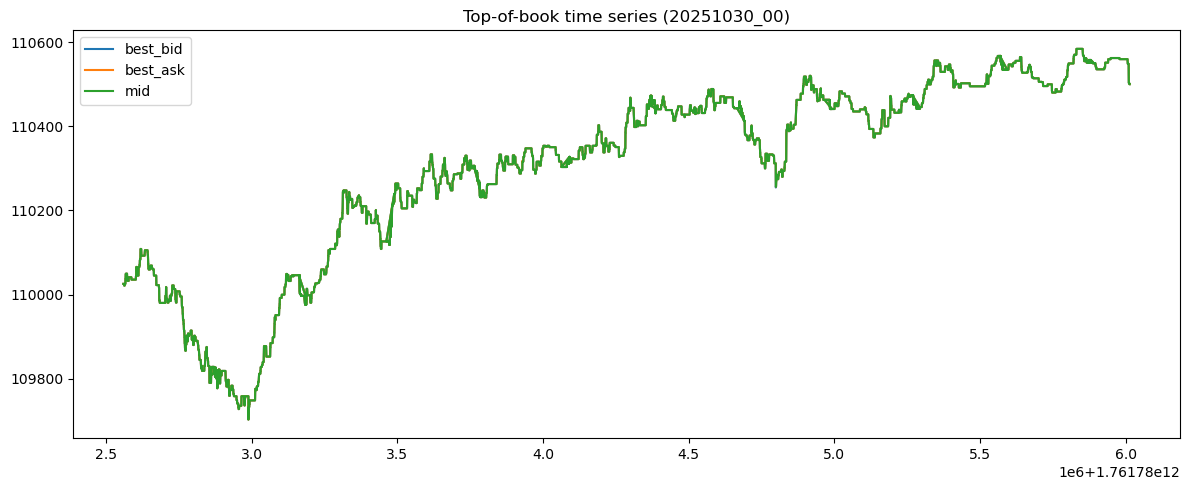

In [58]:
tmp = summary_df.copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tmp["event_time"], tmp["best_bid"], label="best_bid")
ax.plot(tmp["event_time"], tmp["best_ask"], label="best_ask")
ax.plot(tmp["event_time"], tmp["mid"], label="mid")
ax.set_title("Top-of-book time series (20251030_00)")
ax.legend()
plt.tight_layout()
plt.show()

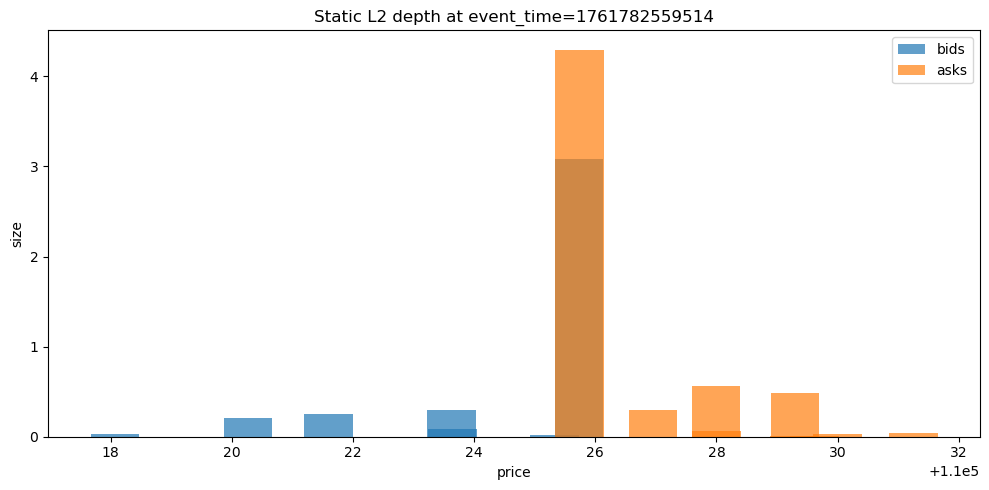

In [59]:
plot_static_l2_depth(topn_df, row_idx=0, n=20)

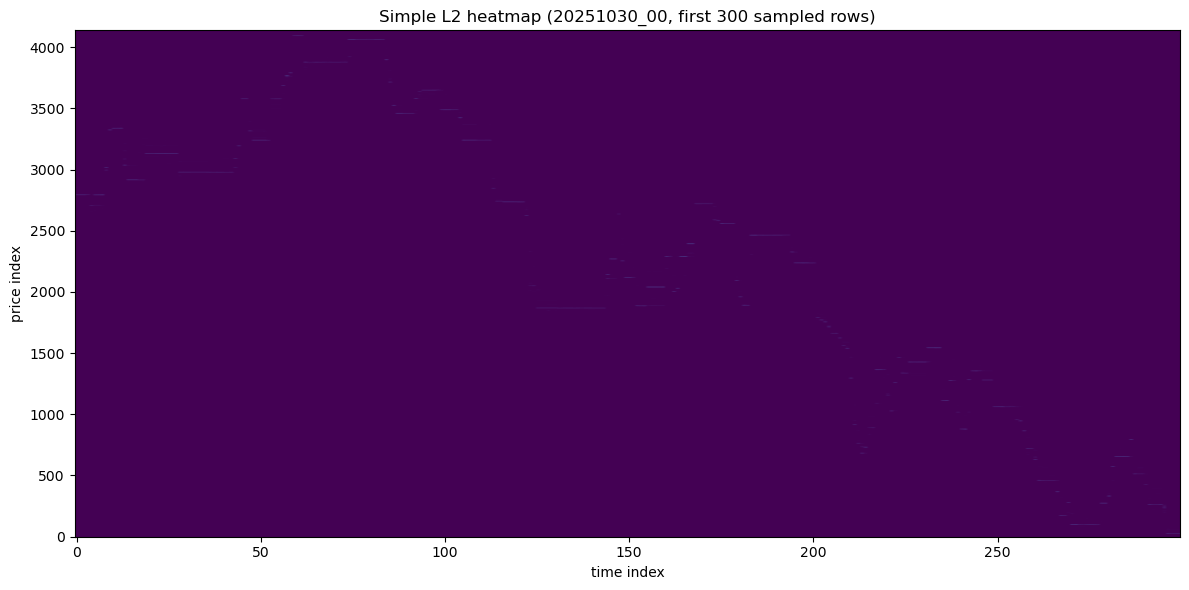

In [63]:
subset = topn_df.iloc[:300].copy()
prices, mat = build_l2_heatmap_matrix(subset, n=20)

plt.figure(figsize=(12, 6))
plt.imshow(mat.T, aspect='auto', origin='lower')
plt.title("Simple L2 heatmap (20251030_00, first 300 sampled rows)")
plt.xlabel("time index")
plt.ylabel("price index")
plt.tight_layout()
plt.show()

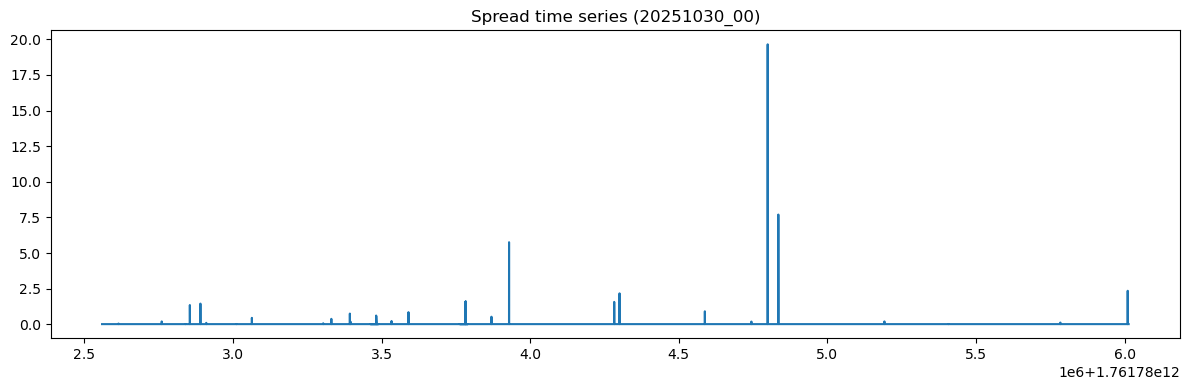

In [64]:
tmp = summary_df.copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tmp["event_time"], tmp["spread"])
ax.set_title("Spread time series (20251030_00)")
plt.tight_layout()
plt.show()

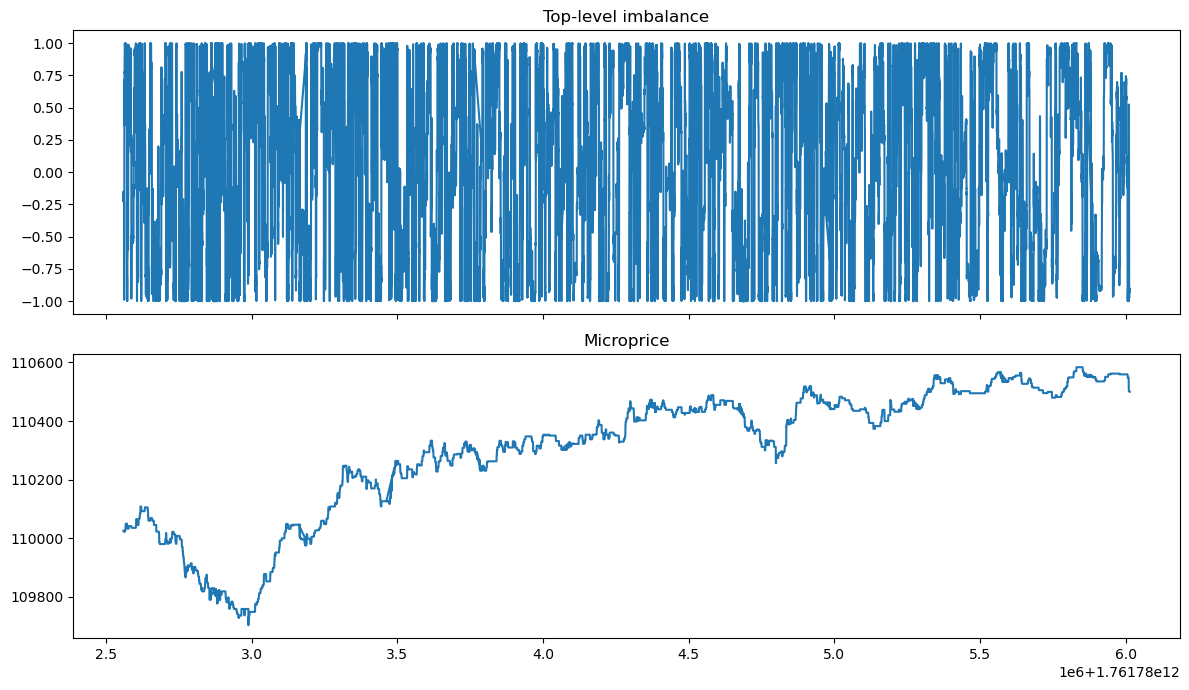

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(tmp["event_time"], tmp["imbalance_1"])
axes[0].set_title("Top-level imbalance")

axes[1].plot(tmp["event_time"], tmp["microprice"])
axes[1].set_title("Microprice")

plt.tight_layout()
plt.show()

In [66]:
def plot_cumulative_l2_depth(topn_df: pd.DataFrame, row_idx: int = 0, n: int = 20):
    row = topn_df.iloc[row_idx]

    bid_px = np.array([row.get(f"bid_px_{i}", np.nan) for i in range(1, n+1)])
    bid_sz = np.array([row.get(f"bid_sz_{i}", np.nan) for i in range(1, n+1)])
    ask_px = np.array([row.get(f"ask_px_{i}", np.nan) for i in range(1, n+1)])
    ask_sz = np.array([row.get(f"ask_sz_{i}", np.nan) for i in range(1, n+1)])

    bid_mask = ~np.isnan(bid_px) & ~np.isnan(bid_sz)
    ask_mask = ~np.isnan(ask_px) & ~np.isnan(ask_sz)

    bid_px = bid_px[bid_mask]
    bid_sz = bid_sz[bid_mask]
    ask_px = ask_px[ask_mask]
    ask_sz = ask_sz[ask_mask]

    bid_cum = np.cumsum(bid_sz)
    ask_cum = np.cumsum(ask_sz)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.step(bid_px, bid_cum, where="mid", label="bid cumulative")
    ax.step(ask_px, ask_cum, where="mid", label="ask cumulative")
    ax.set_title(f"Cumulative L2 depth at event_time={row['event_time']}")
    ax.set_xlabel("price")
    ax.set_ylabel("cumulative size")
    ax.legend()
    plt.tight_layout()
    plt.show()

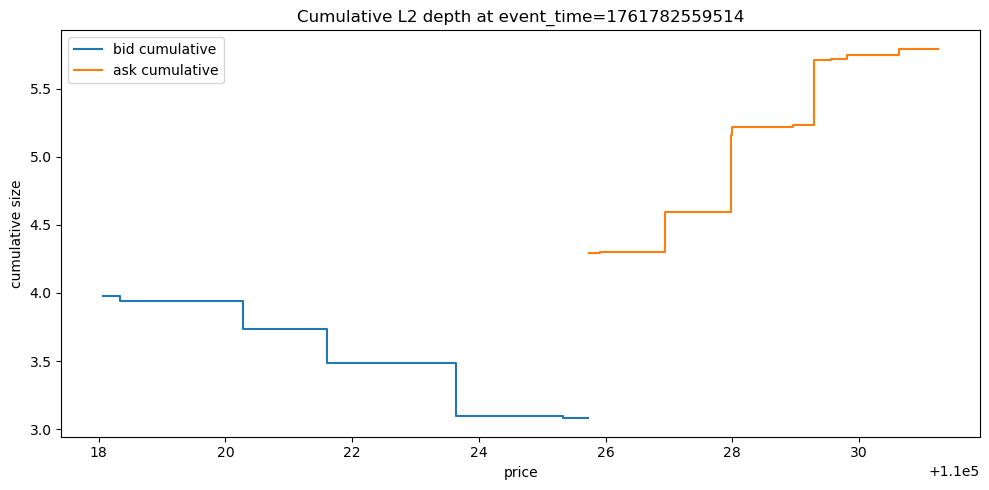

In [67]:
plot_cumulative_l2_depth(topn_df, row_idx=0, n=20)

In [68]:
def plot_cumulative_depth_in_bps(topn_df: pd.DataFrame, row_idx: int = 0, n: int = 20):
    row = topn_df.iloc[row_idx]

    bid_px = np.array([row.get(f"bid_px_{i}", np.nan) for i in range(1, n+1)], dtype=float)
    bid_sz = np.array([row.get(f"bid_sz_{i}", np.nan) for i in range(1, n+1)], dtype=float)
    ask_px = np.array([row.get(f"ask_px_{i}", np.nan) for i in range(1, n+1)], dtype=float)
    ask_sz = np.array([row.get(f"ask_sz_{i}", np.nan) for i in range(1, n+1)], dtype=float)

    best_bid = row.get("bid_px_1", np.nan)
    best_ask = row.get("ask_px_1", np.nan)
    mid = 0.5 * (best_bid + best_ask)

    bid_mask = (~np.isnan(bid_px)) & (~np.isnan(bid_sz))
    ask_mask = (~np.isnan(ask_px)) & (~np.isnan(ask_sz))

    bid_px = bid_px[bid_mask]
    bid_sz = bid_sz[bid_mask]
    ask_px = ask_px[ask_mask]
    ask_sz = ask_sz[ask_mask]

    bid_bps = 1e4 * (bid_px / mid - 1.0)
    ask_bps = 1e4 * (ask_px / mid - 1.0)

    bid_cum = np.cumsum(bid_sz)
    ask_cum = np.cumsum(ask_sz)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.step(bid_bps, bid_cum, where="mid", label="bid cumulative")
    ax.step(ask_bps, ask_cum, where="mid", label="ask cumulative")

    ax.set_title(f"Cumulative depth in bps from mid at event_time={row['event_time']}")
    ax.set_xlabel("distance from mid (bps)")
    ax.set_ylabel("cumulative size")
    ax.legend()
    plt.tight_layout()
    plt.show()

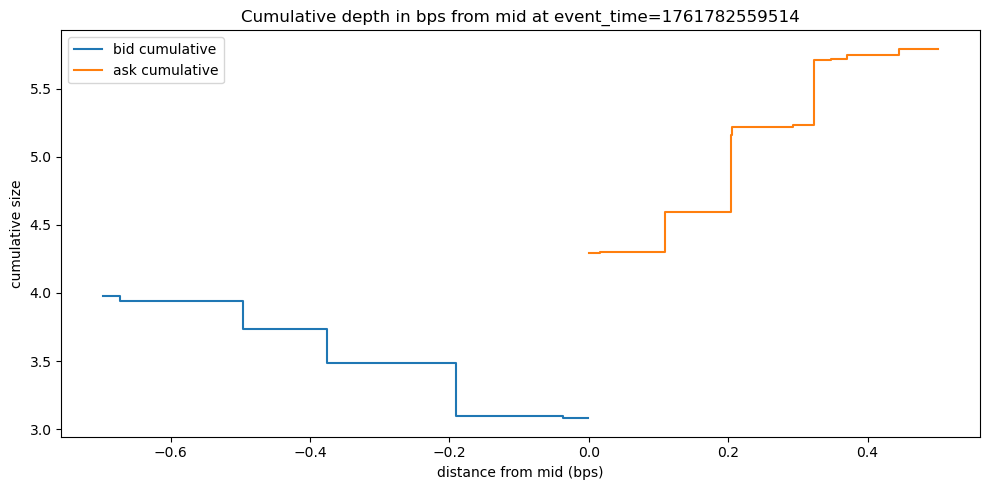

In [69]:
plot_cumulative_depth_in_bps(topn_df, row_idx=0, n=20)

In [70]:
# after fix，now full run again
summary_all = pd.DataFrame()
topn_all = pd.DataFrame()
diag_all = pd.DataFrame()

session_summary_paths = []
session_topn_paths = []
session_diag_paths = []

print("Cleared in-memory result containers.")

Cleared in-memory result containers.


In [71]:
from pathlib import Path

old_files = list(OUTPUT_ROOT.glob("book_event_summary_*.parquet")) \
          + list(OUTPUT_ROOT.glob("book_top20_sampled_*.parquet")) \
          + list(OUTPUT_ROOT.glob("reconstruction_diagnostics_*.parquet")) \
          + list(OUTPUT_ROOT.glob("book_validation_report.parquet")) \
          + list(OUTPUT_ROOT.glob("book_event_summary.parquet")) \
          + list(OUTPUT_ROOT.glob("book_top20_sampled.parquet")) \
          + list(OUTPUT_ROOT.glob("reconstruction_diagnostics.parquet"))

print("n_old_files:", len(old_files))
for f in old_files[:20]:
    print(f.name)

n_old_files: 9472
book_event_summary_20260307_21.parquet
book_event_summary_20251103_03.parquet
book_event_summary_20251217_20.parquet
book_event_summary_20251231_16.parquet
book_event_summary_20251110_10.parquet
book_event_summary_20251222_05.parquet
book_event_summary_20260212_08.parquet
book_event_summary_20251231_06.parquet
book_event_summary_20251103_13.parquet
book_event_summary_20260212_18.parquet
book_event_summary_20251222_15.parquet
book_event_summary_20251204_23.parquet
book_event_summary_20251110_00.parquet
book_event_summary_20260225_18.parquet
book_event_summary_20251215_15.parquet
book_event_summary_20251127_00.parquet
book_event_summary_20260305_14.parquet
book_event_summary_20251206_06.parquet
book_event_summary_20260305_04.parquet
book_event_summary_20251127_10.parquet


In [72]:
for f in old_files:
    f.unlink()

print("Deleted old output parquet files.")

Deleted old output parquet files.


In [ ]:
session_summary_paths = []
session_topn_paths = []
session_diag_paths = []

n_ok = 0
n_fail = 0

for _, rec in session_map.iterrows():
    date = rec["date"]
    hour = rec["hour"]

    snapshot_files = rec["snapshot_files"]
    depthdiff_files = rec["depthdiff_files"]

    if VERBOSE:
        print(f"\n[RUN] {date} {hour}")
        print("  snapshot files :", len(snapshot_files))
        print("  depthdiff files:", len(depthdiff_files))
        print("  depth20 files  :", rec["n_depth20_files"])

    if len(snapshot_files) == 0 or len(depthdiff_files) == 0:
        print(f"[SKIP] {date} {hour} due to missing required files.")
        n_fail += 1
        continue

    try:
        summary_df, topn_df, diag_df = reconstruct_one_session(
            date=date,
            hour=hour,
            snapshot_files=snapshot_files,
            depthdiff_files=depthdiff_files,
            sampled_mode=SAMPLED_MODE,
            sampled_every_ms=SAMPLED_EVERY_MS,
        )

        summary_path = OUTPUT_ROOT / f"book_event_summary_{date}_{hour}.parquet"
        topn_path = OUTPUT_ROOT / f"book_top20_sampled_{date}_{hour}.parquet"
        diag_path = OUTPUT_ROOT / f"reconstruction_diagnostics_{date}_{hour}.parquet"

        summary_df.to_parquet(summary_path, index=False)
        topn_df.to_parquet(topn_path, index=False)
        diag_df.to_parquet(diag_path, index=False)

        session_summary_paths.append(str(summary_path))
        session_topn_paths.append(str(topn_path))
        session_diag_paths.append(str(diag_path))

        aligned_segments = int(diag_df["aligned"].fillna(False).sum()) if len(diag_df) > 0 else 0
        total_segments = len(diag_df)

        print(f"[OK] summary={summary_df.shape}, topn={topn_df.shape}, diag={diag_df.shape}, aligned_segments={aligned_segments}/{total_segments}")
        n_ok += 1

    except Exception as e:
        print(f"[ERROR] {date} {hour}: {e}")
        n_fail += 1

print("\nBatch finished.")
print("n_ok  :", n_ok)
print("n_fail:", n_fail)

In [74]:
summary_all = concat_parquets(session_summary_paths)
topn_all = concat_parquets(session_topn_paths)
diag_all = concat_parquets(session_diag_paths)

print("summary_all shape:", summary_all.shape)
print("topn_all shape   :", topn_all.shape)
print("diag_all shape   :", diag_all.shape)

print("\nAligned segment counts:")
display(
    diag_all.groupby("aligned").size().rename("count").reset_index()
)

print("\nDaily diagnostics summary:")
daily_diag = diag_all.groupby("date").agg(
    n_sessions=("session_id", "nunique"),
    n_segments=("segment_id", "count"),
    aligned_ratio=("aligned", "mean"),
    total_events=("n_events_applied", "sum"),
    total_sequence_gaps=("n_sequence_gaps", "sum"),
    total_crossed_books=("n_crossed_book_events", "sum"),
    total_invalid_events=("n_invalid_events", "sum"),
).reset_index()

display(daily_diag.head(20))

print("\nSummary rows per date:")
if len(summary_all) > 0:
    display(
        summary_all.groupby("date").size().rename("n_summary_rows").reset_index().head(20)
    )

print("\nTopN rows per date:")
if len(topn_all) > 0:
    display(
        topn_all.groupby("date").size().rename("n_topn_rows").reset_index().head(20)
    )

summary_all shape: (5024062, 23)
topn_all shape   : (504079, 88)
diag_all shape   : (1633, 18)

Aligned segment counts:


,aligned,count
0,False,29
1,True,1604



Daily diagnostics summary:


,date,n_sessions,n_segments,aligned_ratio,total_events,total_sequence_gaps,total_crossed_books,total_invalid_events
0,20251030,24,290,0.972414,835375,1,56,0
1,20251031,24,290,0.975862,894699,2,2738,0
2,20251101,24,287,0.975610,890089,0,0,0
3,20251102,24,288,0.993056,875667,1,919,0
4,20251103,24,286,0.982517,896040,0,0,0
5,20251104,16,192,1.000000,632192,0,0,0



Summary rows per date:


,date,n_summary_rows
0,20251030,835375
1,20251031,894699
2,20251101,890089
3,20251102,875667
4,20251103,896040
5,20251104,632192



TopN rows per date:


,date,n_topn_rows
0,20251030,83595
1,20251031,89642
2,20251101,89723
3,20251102,88213
4,20251103,89696
5,20251104,63210
